In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()


df["Churn"].value_counts(normalize=True)
df.dtypes


(7043, 21)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [2]:
missing_values = df.isna().sum()
empty_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
duplicate_rows = df.duplicated().sum()

print("Valeurs manquantes par colonne :")
print(missing_values[missing_values > 0])
print(f"\nValeurs vides dans TotalCharges : {empty_total_charges}")
print(f"Lignes dupliquées : {duplicate_rows}")

print("\nRépartition de la variable cible :")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))

print("\nNombre de modalités par variable catégorielle :")
print(df.select_dtypes(include="object").nunique().sort_values())

Valeurs manquantes par colonne :
Series([], dtype: int64)

Valeurs vides dans TotalCharges : 11
Lignes dupliquées : 0

Répartition de la variable cible :
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Nombre de modalités par variable catégorielle :
gender                 2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
OnlineSecurity         3
InternetService        3
StreamingTV            3
OnlineBackup           3
TechSupport            3
DeviceProtection       3
Contract               3
StreamingMovies        3
MultipleLines          3
PaymentMethod          4
TotalCharges        6531
customerID          7043
dtype: int64


In [3]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
invalid_total_charges = total_charges_numeric.isna()

print("Lignes dont TotalCharges ne peut pas être converti en nombre :")
print(df.loc[invalid_total_charges, ["customerID", "tenure", "TotalCharges"]])
print(f"\nNombre de lignes concernées : {invalid_total_charges.sum()}")
print(f"Tenure de ces clients : {df.loc[invalid_total_charges, 'tenure'].tolist()}")

Lignes dont TotalCharges ne peut pas être converti en nombre :
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             

Nombre de lignes concernées : 11
Tenure de ces clients : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [4]:
df_clean = df.copy()
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"].replace(r"^\s*$", pd.NA, regex=True),
    errors="coerce",
)

print("Type de TotalCharges après nettoyage :", df_clean["TotalCharges"].dtype)
print("Valeurs manquantes après conversion :", df_clean["TotalCharges"].isna().sum())
print("Lignes conservées :", len(df_clean))

Type de TotalCharges après nettoyage : float64
Valeurs manquantes après conversion : 11
Lignes conservées : 7043


Statistiques descriptives des variables numériques :
                 count     mean      std    min     25%      50%      75%  \
SeniorCitizen   7043.0     0.16     0.37   0.00    0.00     0.00     0.00   
tenure          7043.0    32.37    24.56   0.00    9.00    29.00    55.00   
MonthlyCharges  7043.0    64.76    30.09  18.25   35.50    70.35    89.85   
TotalCharges    7032.0  2283.30  2266.77  18.80  401.45  1397.48  3794.74   

                    max  
SeniorCitizen      1.00  
tenure            72.00  
MonthlyCharges   118.75  
TotalCharges    8684.80  


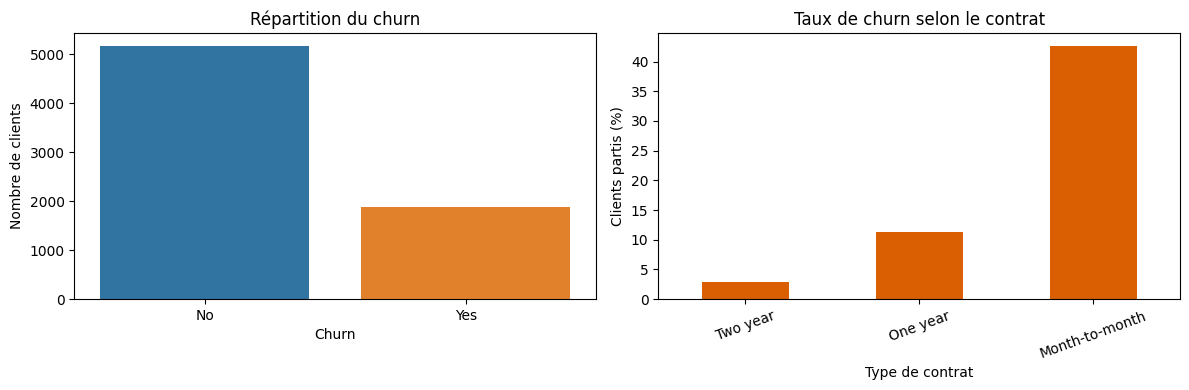

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
print("Statistiques descriptives des variables numériques :")
print(df_clean[numeric_columns].describe().T.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_clean, x="Churn", ax=axes[0], hue="Churn", legend=False)
axes[0].set_title("Répartition du churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Nombre de clients")

contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index",
).mul(100)
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    ax=axes[1],
    color="#d95f02",
)
axes[1].set_title("Taux de churn selon le contrat")
axes[1].set_xlabel("Type de contrat")
axes[1].set_ylabel("Clients partis (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Médianes par statut de churn :
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1683.60
Yes      10.0           79.65        703.55


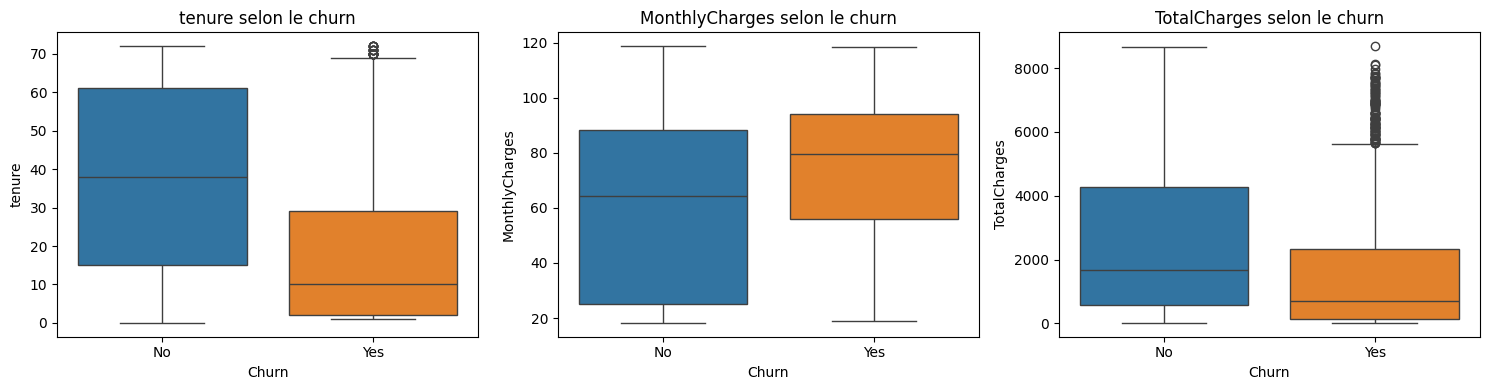

In [6]:
comparison_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
print("Médianes par statut de churn :")
print(df_clean.groupby("Churn")[comparison_columns].median().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, comparison_columns):
    sns.boxplot(data=df_clean, x="Churn", y=column, ax=axis, hue="Churn", legend=False)
    axis.set_title(f"{column} selon le churn")
    axis.set_xlabel("Churn")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

Taux de churn par modalité :

gender :
gender
Female    26.92
Male      26.16
Name: Churn, dtype: float64

Partner :
Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64

Dependents :
Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64

PhoneService :
PhoneService
Yes    26.71
No     24.93
Name: Churn, dtype: float64

MultipleLines :
MultipleLines
Yes                 28.61
No                  25.04
No phone service    24.93
Name: Churn, dtype: float64

InternetService :
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64

OnlineSecurity :
OnlineSecurity
No                     41.77
Yes                    14.61
No internet service     7.40
Name: Churn, dtype: float64

OnlineBackup :
OnlineBackup
No                     39.93
Yes                    21.53
No internet service     7.40
Name: Churn, dtype: float64

DeviceProtection :
DeviceProtection
No                     39.13
Yes                    22.50
No intern

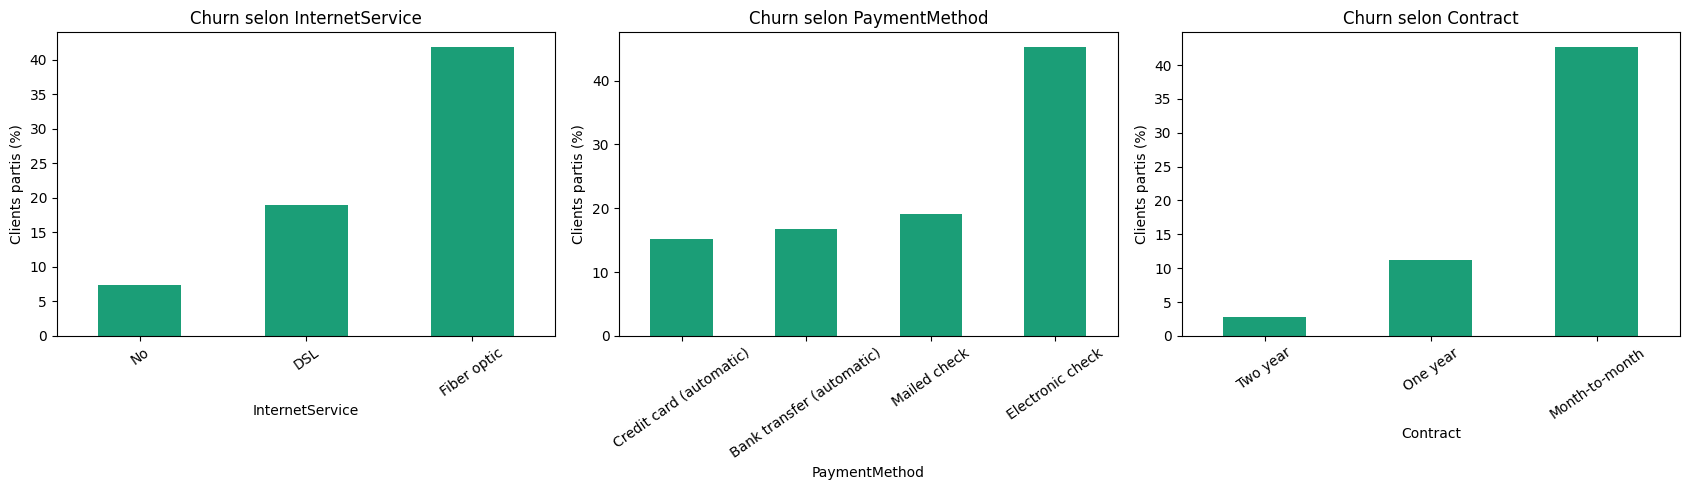

In [7]:
categorical_columns = [
    column
    for column in df_clean.select_dtypes(include="object").columns
    if column not in ["customerID", "Churn"]
]

print("Taux de churn par modalité :")
for column in categorical_columns:
    rates = (
        df_clean.groupby(column)["Churn"]
        .apply(lambda values: (values == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )
    print(f"\n{column} :")
    print(rates)

categorical_plot_columns = ["InternetService", "PaymentMethod", "Contract"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, column in zip(axes, categorical_plot_columns):
    rates = (
        df_clean.groupby(column)["Churn"]
        .apply(lambda values: (values == "Yes").mean() * 100)
        .sort_values()
    )
    rates.plot(kind="bar", ax=axis, color="#1b9e77")
    axis.set_title(f"Churn selon {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Clients partis (%)")
    axis.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()